In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy import sparse

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from forestkernel import LeafEncoder
from forestkernel.prediction.functional import kernel_predict

# Load data and split

In [2]:
seed = 42

X, y = make_regression(
    n_samples=600,
    n_features=20,
    n_informative=8,
    noise=10.0,
    random_state=seed,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=seed,
)

# Fit LeafEncoder

In [3]:
forest = ExtraTreesRegressor(
    n_estimators=500,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=seed,
    verbose=0,
)
forest = RandomForestRegressor(
    n_estimators=500,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=seed,
    verbose=0,
)
# forest = XGBRegressor(
#     n_estimators=100,
#     random_state=seed,
# )

weight_scheme = "oob"

enc = LeafEncoder(
    forest=forest,
    weight_scheme=weight_scheme,
).fit(X_train, y_train)

# Produce leaf maps

In [4]:
Q_train = enc.training_query_map(return_dense=False)
W = enc.reference_map(return_dense=False)
Q_test = enc.transform(X_test, return_dense=False)

print("Q_train shape:", Q_train.shape)
print("W shape:", W.shape)
print("Q_test shape:", Q_test.shape)

K_train = enc.kernel(return_dense=False)
K_test = enc.kernel_extend(X_test, return_dense=False)

print("K_train shape:", K_train.shape)
print("K_test shape:", K_test.shape)

Q_train shape: (300, 188996)
W shape: (300, 188996)
Q_test shape: (300, 188996)
K_train shape: (300, 300)
K_test shape: (300, 300)


# Check row/col sums

In [5]:
def print_sum_stats(name, A):
    row_sums = np.asarray(A.sum(axis=1)).ravel()
    col_sums = np.asarray(A.sum(axis=0)).ravel()

    print(f"\n{name}")
    print(f"  row sums: min={row_sums.min():.6f}, max={row_sums.max():.6f}, mean={row_sums.mean():.6f}")
    print(f"  col sums: min={col_sums.min():.6f}, max={col_sums.max():.6f}, mean={col_sums.mean():.6f}")
    print(f"  nnz: {A.nnz if sparse.issparse(A) else np.count_nonzero(A)}")


print_sum_stats("K_train", K_train)
print_sum_stats("K_test", K_test)


K_train
  row sums: min=4.462846, max=6.285283, mean=5.344657
  col sums: min=4.462846, max=6.285283, mean=5.344657
  nnz: 22330

K_test
  row sums: min=1.917417, max=3.290477, mean=2.673686
  col sums: min=1.495193, max=3.849055, mean=2.673686
  nnz: 33136


# Raw PCA vs Leaf PCA comparison

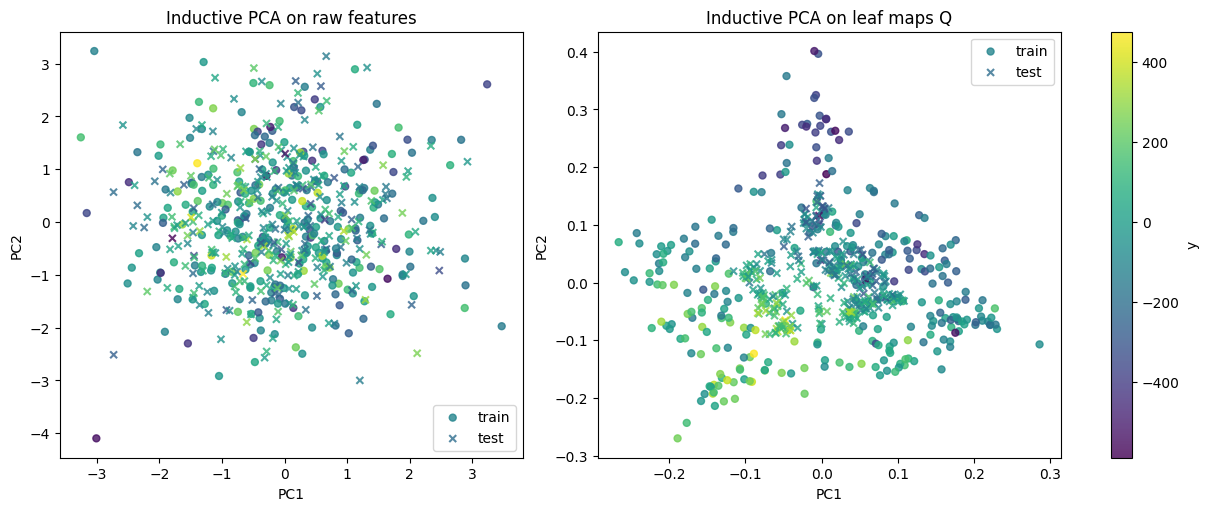

In [6]:
# Shared plotting metadata
y_all = np.concatenate([y_train, y_test])
split_all = np.array(["train"] * len(X_train) + ["test"] * len(X_test))

# Raw feature PCA: fit on train, project test
pca_raw = PCA(n_components=2, random_state=seed)
Z_raw_train = pca_raw.fit_transform(X_train)
Z_raw_test = pca_raw.transform(X_test)
Z_raw = np.vstack([Z_raw_train, Z_raw_test])

# Leaf-map PCA: fit on train Q, project test Q
pca_q = PCA(n_components=2, random_state=seed)
Z_q_train = pca_q.fit_transform(Q_train)
Z_q_test = pca_q.transform(Q_test)
Z_q = np.vstack([Z_q_train, Z_q_test])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, Z, title in zip(
    axes,
    [Z_raw, Z_q],
    ["Inductive PCA on raw features", "Inductive PCA on leaf maps Q"],
):
    for split, marker in [("train", "o"), ("test", "x")]:
        mask = split_all == split
        sc = ax.scatter(
            Z[mask, 0],
            Z[mask, 1],
            c=y_all[mask],
            marker=marker,
            s=25,
            alpha=0.8,
            label=split,
        )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

fig.colorbar(sc, ax=axes, label="y")
plt.show()

In [7]:
for scheme in ["uniform", "kerf", "gap"]:
    enc_scheme = LeafEncoder(
        forest=forest,
        weight_scheme=scheme,
    ).fit(X_train, y_train)

    y_pred_kernel = kernel_predict(
        Q=enc_scheme.transform(X_test, return_dense=False),
        W=enc_scheme.reference_map(return_dense=False),
        y_train=y_train,
        weight_scheme=scheme,
        prediction_type="regression",
    )

    y_pred_forest = enc_scheme.forest_.predict(X_test)

    print(
        f"{scheme:<8} "
        f"kernel_RMSE={root_mean_squared_error(y_test, y_pred_kernel):.3f} "
        f"kernel_R2={r2_score(y_test, y_pred_kernel):.3f} | "
        f"forest_RMSE={root_mean_squared_error(y_test, y_pred_forest):.3f} "
        f"forest_R2={r2_score(y_test, y_pred_forest):.3f} | "
        f"agreement_RMSE={root_mean_squared_error(y_pred_forest, y_pred_kernel):.3f} "
        f"agreement_R2={r2_score(y_pred_forest, y_pred_kernel):.3f}"
    )

uniform  kernel_RMSE=94.661 kernel_R2=0.692 | forest_RMSE=88.626 forest_R2=0.730 | agreement_RMSE=9.968 agreement_R2=0.993
kerf     kernel_RMSE=91.297 kernel_R2=0.714 | forest_RMSE=88.626 forest_R2=0.730 | agreement_RMSE=5.183 agreement_R2=0.998
gap      kernel_RMSE=88.626 kernel_R2=0.730 | forest_RMSE=88.626 forest_R2=0.730 | agreement_RMSE=0.000 agreement_R2=1.000
